Name- Hemani Panchmatiya

LOADING THE LIBRARIES

In [83]:
import os, shutil, random
import zipfile
import tensorflow as tf
import keras
import numpy as np
import tensorflow as tf
from keras import layers
from keras.utils import image_dataset_from_directory
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator


DOWNLOADING THE DATASET


In [84]:
from google.colab import files
uploaded = files.upload()

Saving cats_vs_dogs_small.zip to cats_vs_dogs_small (1).zip


In [114]:
zip_file_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Extracted successfully!")

Extracted successfully!


In [115]:
for root, dirs, files in os.walk("dataset"):
    print(root)

dataset
dataset/cats_vs_dogs_small
dataset/cats_vs_dogs_small/test
dataset/cats_vs_dogs_small/test/dogs
dataset/cats_vs_dogs_small/test/cats
dataset/cats_vs_dogs_small/validation
dataset/cats_vs_dogs_small/validation/dogs
dataset/cats_vs_dogs_small/validation/cats
dataset/cats_vs_dogs_small/train
dataset/cats_vs_dogs_small/train/dogs
dataset/cats_vs_dogs_small/train/cats


In [116]:
!ls dataset
!ls dataset/*

cats_vs_dogs_small
test  train  validation


LOADING THE DATASET

In [117]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    "dataset/cats_vs_dogs_small/train",
    image_size=(180,180),
    batch_size=32
)

validation_dataset = image_dataset_from_directory(
    "dataset/cats_vs_dogs_small/validation",
    image_size=(180,180),
    batch_size=32
)

test_dataset = image_dataset_from_directory(
    "dataset/cats_vs_dogs_small/test",
    image_size=(180,180),
    batch_size=32
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


USING TRAIN = 500 DATASET

In [121]:
train_dataset_small = train_dataset.take(32)  # ~1000 images (32 batches × 32)

VERIFY DATASET

In [118]:
print(train_dataset.class_names)

['cats', 'dogs']


ADD DATA AUGMENTATION

In [119]:
from tensorflow.keras import layers
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

OPTIMIZE PERFORMANCE

In [120]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

BUILD IMPROVED MODEL

In [122]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model():
    inputs = keras.Input(shape=(180,180,3))

    x = layers.Rescaling(1./255)(inputs)

    x = layers.Conv2D(32,3,activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64,3,activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128,3,activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128,3,activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

TRAIN MODEL

In [123]:
model = build_model()

callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
]

history = model.fit(
    train_dataset,
    epochs=15,
    validation_data=validation_dataset,
    callbacks=callbacks
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 168s 3s/step - accuracy: 0.5165 - loss: 0.6953 - val_accuracy: 0.4980 - val_loss: 0.6916
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.5010 - loss: 0.6938 - val_accuracy: 0.5830 - val_loss: 0.6882
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.5280 - loss: 0.6889 - val_accuracy: 0.5610 - val_loss: 0.6852
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.5340 - loss: 0.6896 - val_accuracy: 0.5710 - val_loss: 0.6866
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.5440 - loss: 0.6873 - val_accuracy: 0.5910 - val_loss: 0.6789
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 207s 3s/step - accuracy: 0.5610 - loss: 0.6833 - val_accuracy: 0.5390 - val_loss: 0.6769
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.5795 - loss: 0.6687 - val_accuracy: 0.6190 - val_loss: 0.6490
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.6095 - loss: 0.6686 - val_accuracy: 0.5270 - v

In [124]:
test_loss, test_acc = model.evaluate(test_dataset)
print("Test Accuracy:", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 595ms/step - accuracy: 0.6580 - loss: 0.6278
Test Accuracy: 0.6579999923706055


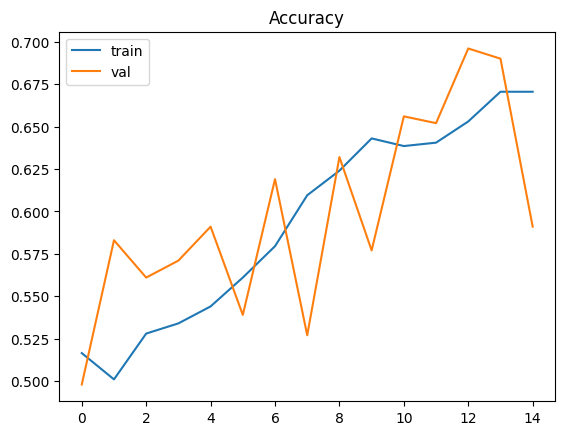

In [125]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

Validation sampling

In [127]:
validation_dataset_small = validation_dataset.take(16)  # ~512 images

In [128]:
model = build_model()

callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
]

history = model.fit(
    train_dataset_small,
    epochs=15,
    validation_data=validation_dataset_small,  # ✅ fixed
    callbacks=callbacks
)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.5029 - loss: 0.6992 - val_accuracy: 0.5020 - val_loss: 0.6927
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.5039 - loss: 0.6930 - val_accuracy: 0.4902 - val_loss: 0.6927
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.5059 - loss: 0.6926 - val_accuracy: 0.5332 - val_loss: 0.6896
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.5234 - loss: 0.6889 - val_accuracy: 0.5391 - val_loss: 0.6829
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.5430 - loss: 0.6870 - val_accuracy: 0.5254 - val_loss: 0.6865
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.5254 - loss: 0.6940 - val_accuracy: 0.5527 - val_loss: 0.6886
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.5693 - loss: 0.6844 - val_accuracy: 0.5781 - val_loss: 0.6788
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.5371 - loss: 0.6823 - val_accuracy: 0.5605 - val_los

In [126]:
test_dataset_small = test_dataset.take(16)
model.evaluate(test_dataset_small)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 669ms/step - accuracy: 0.6562 - loss: 0.6337


[0.6337318420410156, 0.65625]

**Question 2:** Increase your training sample size. You may pick any amount. Keep the validation and
test samples the same as above. Optimize your network (again training from scratch).
What performance did you achieve?

Re-Load Dataset

In [186]:
train_q2 = image_dataset_from_directory(
    "dataset/cats_vs_dogs_small/train",
    image_size=(180,180),
    batch_size=32
).shuffle(1000)

Found 2000 files belonging to 2 classes.


Data Augmentation

In [187]:
train_q2 = train_q2.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

In [188]:
train_q2 = train_q2.take(47)
val_q2 = val_q2.take(16)
test_q2 = test_q2.take(16)

In [189]:
AUTOTUNE = tf.data.AUTOTUNE

train_q2 = train_q2.cache().prefetch(AUTOTUNE)
val_q2 = val_q2.cache().prefetch(AUTOTUNE)
test_q2 = test_q2.cache().prefetch(AUTOTUNE)

OPTIMIZED MODEL

In [190]:
def build_model_q2():
    inputs = keras.Input(shape=(180,180,3))
    x = layers.Rescaling(1./255)(inputs)

    x = layers.Conv2D(32,3,activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64,3,activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128,3,activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1,activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(0.0005), loss="binary_crossentropy", metrics=["accuracy"])

    return model

TRAIN MODEL

In [191]:
model = build_model_q2()

history = model.fit(
    train_q2,
    epochs=15,
    validation_data=val_q2,
    callbacks=[keras.callbacks.EarlyStopping(patience=4)]
)

test_acc_q2 = model.evaluate(test_q2)[1]
print("Q2 Accuracy:", test_acc_q2)

Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.5585 - loss: 0.7539 - val_accuracy: 0.5234 - val_loss: 0.6926
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.5867 - loss: 0.7063 - val_accuracy: 0.5078 - val_loss: 0.6927
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.5806 - loss: 0.6987 - val_accuracy: 0.5098 - val_loss: 0.6950
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.6022 - loss: 0.6758 - val_accuracy: 0.5039 - val_loss: 0.7203
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.5901 - loss: 0.6916 - val_accuracy: 0.5020 - val_loss: 0.7342
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 660ms/step - accuracy: 0.5078 - loss: 0.7340
Q2 Accuracy: 0.5078125


PLOT GRAPH

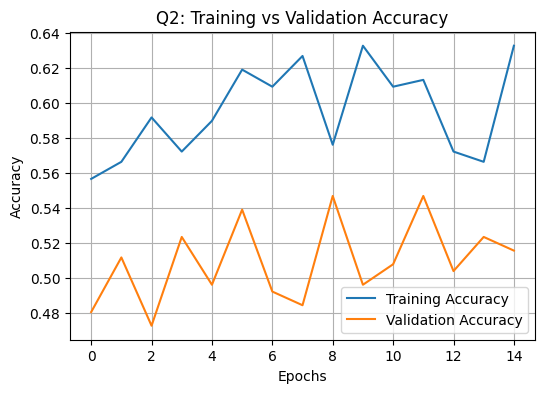

In [184]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Q2: Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

Question 3: Now change your training sample so that you achieve better performance than those
from Steps 1 and 2. This sample size may be larger, or smaller than those in the previous
steps. The objective is to find the ideal training sample size to get best prediction
results.

LOAD DATASET

In [160]:
train_q3 = image_dataset_from_directory("dataset/cats_vs_dogs_small/train", image_size=(180,180), batch_size=32)
val_q3 = image_dataset_from_directory("dataset/cats_vs_dogs_small/validation", image_size=(180,180), batch_size=32)
test_q3 = image_dataset_from_directory("dataset/cats_vs_dogs_small/test", image_size=(180,180), batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


REDUCE DATASET SIZE

In [161]:
train_q3 = train_q3.take(16)   # ~500
val_q3 = val_q3.take(8)        # ~250
test_q3 = test_q3.take(8)

DATA AUGMENTATION

In [162]:
train_q3 = train_q3.map(lambda x, y: (data_augmentation(x, training=True), y))

Model

In [163]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model_q3():
    inputs = keras.Input(shape=(180,180,3))

    x = layers.Rescaling(1./255)(inputs)

    x = layers.Conv2D(32,3,activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64,3,activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128,3,activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

TRAIN MODEL

In [165]:
model = build_model_q3()

callbacks = [
    keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)
]

history = model.fit(
    train_q3,
    epochs=15,
    validation_data=val_q3,
    callbacks=callbacks
)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step - accuracy: 0.5566 - loss: 0.7952 - val_accuracy: 0.4805 - val_loss: 0.6922
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.5664 - loss: 0.7402 - val_accuracy: 0.5117 - val_loss: 0.6931
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.5918 - loss: 0.7367 - val_accuracy: 0.4727 - val_loss: 0.7035
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.5723 - loss: 0.7396 - val_accuracy: 0.5234 - val_loss: 0.6922
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.5898 - loss: 0.7006 - val_accuracy: 0.4961 - val_loss: 0.6934
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - accuracy: 0.6191 - loss: 0.6966 - val_accuracy: 0.5391 - val_loss: 0.6868
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.6094 - loss: 0.6765 - val_accuracy: 0.4922 - val_loss: 0.6962
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.6270 - loss: 0.7069 - val_accuracy: 0.4844 - val_loss:

Evaluate

In [166]:
test_loss, test_acc_q3 = model.evaluate(test_q3)
print("Q3 Test Accuracy:", test_acc_q3)

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 575ms/step - accuracy: 0.5117 - loss: 0.6882
Q3 Test Accuracy: 0.51171875


Plotting the graph

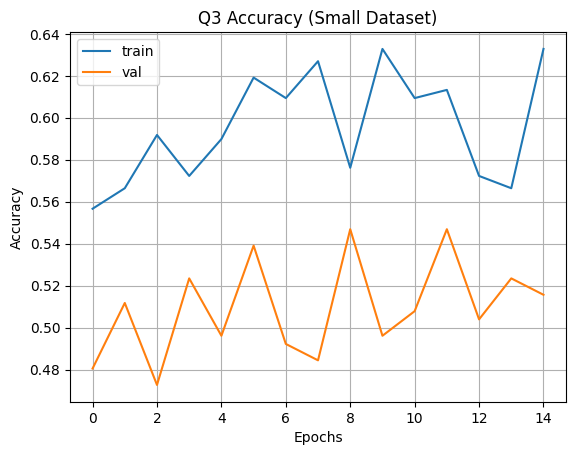

In [167]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Q3 Accuracy (Small Dataset)")

plt.legend()
plt.grid()
plt.show()

Question 4: Repeat Steps 1-3, but now using a pretrained network. The sample sizes you use in
Steps 2 and 3 for the pretrained network may be the same or different from those using
the network where you trained from scratch. Again, use any and all optimization
techniques to get best performance.


Load Dataset

In [168]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    "dataset/cats_vs_dogs_small/train",
    image_size=(180,180),
    batch_size=32
)

validation_dataset = image_dataset_from_directory(
    "dataset/cats_vs_dogs_small/validation",
    image_size=(180,180),
    batch_size=32
)

test_dataset = image_dataset_from_directory(
    "dataset/cats_vs_dogs_small/test",
    image_size=(180,180),
    batch_size=32
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


CREATE DATASET VARIATIONS

In [169]:
# Q1 (~1000)
train_small = train_dataset.take(32)

# Q2 (~2000)
train_medium = train_dataset.take(64)

# Q3 (~500)
train_tiny = train_dataset.take(16)

# Validation/Test SAME as before (~500)
val_small = validation_dataset.take(16)
test_small = test_dataset.take(16)

DATA AUGMENTATION

In [170]:
from tensorflow.keras import layers
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

def augment(dataset):
    return dataset.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(tf.data.AUTOTUNE)

BUILD PRETRAINED MODEL

In [171]:
from tensorflow.keras.applications import VGG16
from tensorflow import keras
from tensorflow.keras import layers

def build_pretrained():
    conv_base = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(180,180,3)
    )

    conv_base.trainable = False  # Freeze pretrained layers

    inputs = keras.Input(shape=(180,180,3))
    x = layers.Rescaling(1./255)(inputs)

    x = conv_base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0003),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

TRAIN FUNCTION

In [177]:
def train_model(train_data, title):
    # Build fresh model every time
    model = build_pretrained()

    # Train
    history = model.fit(
        augment(train_data),
        epochs=10,
        validation_data=val_small,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
        ]
    )

    # ✅ Evaluate on test data
    test_loss, test_acc = model.evaluate(test_small)

    # ✅ Print result (important for assignment)
    print(f"{title} Test Accuracy: {test_acc:.4f}")

    # ✅ Return values for comparison/plots
    return history, test_acc

Run Experiment

In [ ]:
datasets = {
    "Pretrained Q1 (~1000)": train_small,
    "Pretrained Q2 (~1500)": train_medium,
    "Pretrained Q3 (~500)": train_tiny
}

results = {}

for name, data in datasets.items():
    print(f"\nRunning {name}...")
    history, acc = train_model(data, name)
    results[name] = acc

Results Comparison

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Experiment": ["Pretrained Q1", "Pretrained Q2", "Pretrained Q3"],
    "Accuracy": [acc1, acc2, acc3]
})

df